<a href="https://colab.research.google.com/github/derewor/Alzheimer-drug-discovery/blob/main/Parkinson_Disease_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#**Connect with the chEMBL database**

In [2]:
# import all target molecules from the chEMBL database
# first install the chEMBL database.
! pip install chembl_webresource_client

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 5.5 MB/s eta 0:00:00


In [3]:
# import new-client
from chembl_webresource_client.new_client import new_client

In [11]:
# import the target molecules form the chEMBL database.
target = new_client.target
target_df = pd.DataFrame(target.search('Alzheimer'))
target_df

,cross_references,organism,pref_name,score,species_group_flag,target_chembl_id,target_components,target_type,tax_id
0,[],Homo sapiens,Nucleosome-remodeling factor subunit BPTF,13.0,False,CHEMBL3085621,"[{'accession': 'Q12830', 'component_descriptio...",SINGLE PROTEIN,9606
1,[],Homo sapiens,Nicastrin,12.0,False,CHEMBL3418,"[{'accession': 'Q92542', 'component_descriptio...",SINGLE PROTEIN,9606
2,[],Homo sapiens,Gamma-secretase,12.0,False,CHEMBL2094135,"[{'accession': 'Q96BI3', 'component_descriptio...",PROTEIN COMPLEX,9606
3,[],Homo sapiens,Protein cereblon/Nucleosome-remodeling factor ...,12.0,False,CHEMBL6195548,"[{'accession': 'Q12830', 'component_descriptio...",PROTEIN-PROTEIN INTERACTION,9606
4,[],Rattus norvegicus,Amyloid-beta precursor protein,9.0,False,CHEMBL3638365,"[{'accession': 'P08592', 'component_descriptio...",SINGLE PROTEIN,10116
5,[],Mus musculus,Amyloid-beta precursor protein,8.0,False,CHEMBL4523942,"[{'accession': 'P12023', 'component_descriptio...",SINGLE PROTEIN,10090
6,[],Homo sapiens,Amyloid-beta precursor protein,7.0,False,CHEMBL2487,"[{'accession': 'P05067', 'component_descriptio...",SINGLE PROTEIN,9606


In [17]:
# select the target chambel_id
selected_target = target_df.target_chembl_id[2]
selected_target

'CHEMBL2094135'

In [18]:
# Now extract the activity data for the selected target enzyme.
activity = new_client.activity
res_activity = activity.filter(target_chembl_id = selected_target)#.filter(standard_type = "IC50")
res_act_df = pd.DataFrame(res_activity)
res_act_df.shape

(4930, 47)

In [23]:
# filter out rows where the actiity standard type is IC50
res_df = res_act_df.query('standard_type == "IC50"')
res_df.shape

(3546, 47)

In [24]:
# sace the data as csv.
res_df.to_csv('gsecretase_bioactivity_data.csv', index=False)

## **1.Data Wrangling**

In [25]:
res_df.columns

Index(['action_type', 'activity_comment', 'activity_id', 'activity_properties',
       'assay_chembl_id', 'assay_description', 'assay_type',
       'assay_variant_accession', 'assay_variant_mutation', 'bao_endpoint',
       'bao_format', 'bao_label', 'canonical_smiles', 'data_validity_comment',
       'data_validity_description', 'document_chembl_id', 'document_journal',
       'document_year', 'ligand_efficiency', 'modality', 'molecule_chembl_id',
       'molecule_pref_name', 'parent_molecule_chembl_id', 'pchembl_value',
       'potential_duplicate', 'qudt_units', 'record_id', 'relation', 'src_id',
       'standard_flag', 'standard_relation', 'standard_text_value',
       'standard_type', 'standard_units', 'standard_upper_value',
       'standard_value', 'target_chembl_id', 'target_organism',
       'target_pref_name', 'target_tax_id', 'text_value', 'toid', 'type',
       'units', 'uo_units', 'upper_value', 'value'],
      dtype='object')

In [26]:
# select only desired features
selected_columns = ['molecule_chembl_id', 'canonical_smiles','standard_units', 'standard_value','value','potential_duplicate','standard_type']
act_df = res_df[selected_columns]
act_df.head()

,molecule_chembl_id,canonical_smiles,standard_units,standard_value,value,potential_duplicate,standard_type
12,CHEMBL336071,C[C@@H](Cc1ccc(F)c(F)c1)C(=O)N[C@H]1N=C(c2ccc3...,nM,1.8,1.8,0,IC50
13,CHEMBL336813,C[C@@H](Cc1ccc(F)c(F)c1)C(=O)N[C@H]1N=C(c2ccc3...,nM,0.9,0.9,0,IC50
14,CHEMBL334594,C[C@@H](Cc1ccc(F)c(F)c1)C(=O)N[C@H]1N=C(c2ccc3...,nM,13.2,13.2,0,IC50
15,CHEMBL133237,C[C@@H](Cc1ccc(F)c(F)c1)C(=O)N[C@H]1N=C(c2ccc3...,nM,1.2,1.2,0,IC50
16,CHEMBL132900,C[C@@H](Cc1ccc(F)c(F)c1)C(=O)N[C@H]1N=C(c2ccc3...,nM,1884.0,1884.0,0,IC50


In [27]:
# check the data types of the selected featuers
act_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3546 entries, 12 to 4929
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   molecule_chembl_id   3546 non-null   object
 1   canonical_smiles     3546 non-null   object
 2   standard_units       3517 non-null   object
 3   standard_value       3516 non-null   object
 4   value                3516 non-null   object
 5   potential_duplicate  3546 non-null   int64 
 6   standard_type        3546 non-null   object
dtypes: int64(1), object(6)
memory usage: 221.6+ KB


In [28]:
# The standard value and value features need to be a float.
act_df['standard_value'] = act_df['standard_value'].astype(float)
act_df['value'] = act_df['value'].astype(float)
# Check if there are missing values in the dataframe, mainly in the chambl_id and standard_value. drop missing values.
act_df1 = act_df.dropna()
act_df1.shape

/tmp/ipykernel_2343/2260118385.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  act_df['standard_value'] = act_df['standard_value'].astype(float)
/tmp/ipykernel_2343/2260118385.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  act_df['value'] = act_df['value'].astype(float)


(3516, 7)

In [30]:
# check if there are duplicated values.
act_df1.potential_duplicate.value_counts().reset_index()

,potential_duplicate,count
0,0,3416
1,1,100


In [31]:
# extract non duplicated entries.
act_df2 = act_df1.query("potential_duplicate == 0")
act_df2.shape

(3416, 7)

In [32]:
# Describe the standard value of the filtered df.
act_df2.standard_value.describe() # the mean and median values indicate that the data is highly skewed.

,standard_value
count,3416.000000
mean,6134.732725
std,19177.447115
min,0.002000
25%,20.000000
50%,150.500000
75%,1640.000000
max,332000.000000


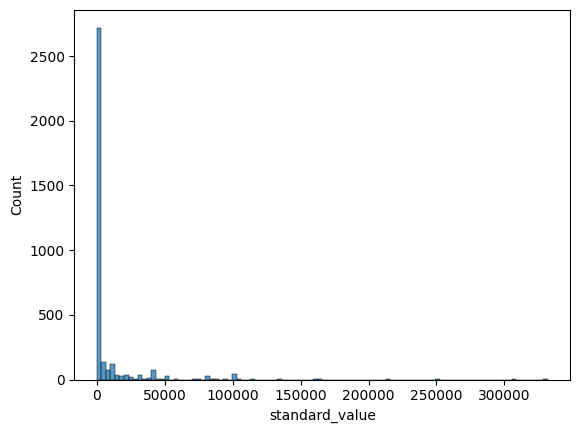

In [35]:
# observe the distribution of the standard type.
sns.histplot(act_df2['standard_value'], bins=100)
plt.show()

In [37]:
# define a function that categorizes molecule based on the standard value.
def activity_category(value):
  if value >= 10000:
    return 'inactive'
  elif value >= 1000:
    return 'weekly_active'
  elif value >= 100:
    return 'active'
  else:
    return 'potent'

act_df2['activity_class'] = act_df2['standard_value'].apply(activity_category)
act_df2.head()

/tmp/ipykernel_2343/3707800158.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  act_df2['activity_class'] = act_df2['standard_value'].apply(activity_category)


,molecule_chembl_id,canonical_smiles,standard_units,standard_value,value,potential_duplicate,standard_type,activity_class
12,CHEMBL336071,C[C@@H](Cc1ccc(F)c(F)c1)C(=O)N[C@H]1N=C(c2ccc3...,nM,1.8,1.8,0,IC50,potent
13,CHEMBL336813,C[C@@H](Cc1ccc(F)c(F)c1)C(=O)N[C@H]1N=C(c2ccc3...,nM,0.9,0.9,0,IC50,potent
14,CHEMBL334594,C[C@@H](Cc1ccc(F)c(F)c1)C(=O)N[C@H]1N=C(c2ccc3...,nM,13.2,13.2,0,IC50,potent
15,CHEMBL133237,C[C@@H](Cc1ccc(F)c(F)c1)C(=O)N[C@H]1N=C(c2ccc3...,nM,1.2,1.2,0,IC50,potent
16,CHEMBL132900,C[C@@H](Cc1ccc(F)c(F)c1)C(=O)N[C@H]1N=C(c2ccc3...,nM,1884.0,1884.0,0,IC50,weekly_active


In [38]:
# convert the standard_values into Molar by multiplying with 10 -9
act_df2['IC50'] = act_df2['standard_value'] * 10**-9
# Then -log trasnform the ic50 feature.
act_df2['log_IC50'] = -np.log10(act_df2['IC50'])
act_df2.head()

/tmp/ipykernel_2343/2207861225.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  act_df2['IC50'] = act_df2['standard_value'] * 10**-9
/tmp/ipykernel_2343/2207861225.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  act_df2['log_IC50'] = -np.log10(act_df2['IC50'])


,molecule_chembl_id,canonical_smiles,standard_units,standard_value,value,potential_duplicate,standard_type,activity_class,IC50,log_IC50
12,CHEMBL336071,C[C@@H](Cc1ccc(F)c(F)c1)C(=O)N[C@H]1N=C(c2ccc3...,nM,1.8,1.8,0,IC50,potent,1.800000e-09,8.744727
13,CHEMBL336813,C[C@@H](Cc1ccc(F)c(F)c1)C(=O)N[C@H]1N=C(c2ccc3...,nM,0.9,0.9,0,IC50,potent,9.000000e-10,9.045757
14,CHEMBL334594,C[C@@H](Cc1ccc(F)c(F)c1)C(=O)N[C@H]1N=C(c2ccc3...,nM,13.2,13.2,0,IC50,potent,1.320000e-08,7.879426
15,CHEMBL133237,C[C@@H](Cc1ccc(F)c(F)c1)C(=O)N[C@H]1N=C(c2ccc3...,nM,1.2,1.2,0,IC50,potent,1.200000e-09,8.920819
16,CHEMBL132900,C[C@@H](Cc1ccc(F)c(F)c1)C(=O)N[C@H]1N=C(c2ccc3...,nM,1884.0,1884.0,0,IC50,weekly_active,1.884000e-06,5.724919


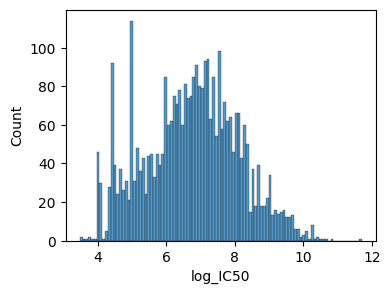

In [39]:
# observe the distribution of the log transformed feature.
plt.figure(figsize=(4,3))
sns.histplot(act_df2['log_IC50'], bins=100)
plt.show()

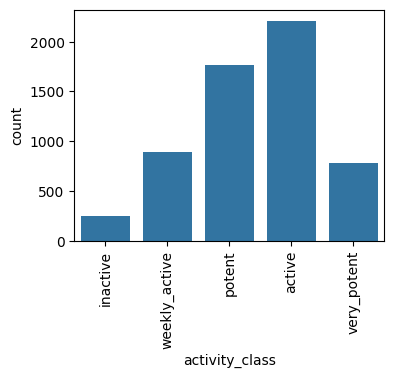

In [ ]:
# determine the number of compounds per activity class and plot it.
plt.figure(figsize=(4,3))
sns.countplot(x='activity_class', data=act_df2)
plt.xticks(rotation=90)
plt.show()

In [ ]:
act_df2.columns

Index(['molecule_chembl_id', 'canonical_smiles', 'standard_units',
       'standard_value', 'value', 'potential_duplicate', 'standard_type',
       'activity_class', 'IC50', 'log_IC50'],
      dtype='object')

In [ ]:
# select only required features.
features_needed = ['molecule_chembl_id','canonical_smiles','log_IC50', 'activity_class']
act_df3 = act_df2[features_needed]
act_df3.head()

,molecule_chembl_id,canonical_smiles,log_IC50,activity_class
0,CHEMBL1771409,Cc1cc(N/N=C/c2ccc(O)c(O)c2)nc2ccccc12,4.879426,inactive
1,CHEMBL1771411,Cc1cc(N/N=C/c2ccncc2)nc2ccccc12,5.387216,weekly_active
2,CHEMBL1933288,C[C@@H]1CCNC(=O)c2cc3ccc(C(=O)Nc4nc5ccccc5n4CC...,7.795880,potent
3,CHEMBL2012582,COc1cc(C(=O)N2CCC(N3CCN(C)CC3)CC2)ccc1Nc1ncc2c...,7.886057,potent
4,CHEMBL509032,COc1cc(N2CCC(N3CCN(C)CC3)CC2)ccc1Nc1ncc(Cl)c(N...,8.107905,potent


##**2. Exploratory Data Analysis (EDA)**

### To calculate the Lipnski descriptors install conda and rdkit.
##**Install rdkit**

In [ ]:
! pip install rdkit

In [ ]:
# import chem and then Lipinski from chem.
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski

In [ ]:
# Add the RDKit molecule for each compound by using the Chem.MolFromSmiles function.
act_df3["mol"] = act_df3["canonical_smiles"].apply(Chem.MolFromSmiles)

/tmp/ipykernel_133269/1795960794.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  act_df3["mol"] = act_df3["canonical_smiles"].apply(Chem.MolFromSmiles)


In [ ]:
act_df3.head()

,molecule_chembl_id,canonical_smiles,log_IC50,activity_class,mol
0,CHEMBL1771409,Cc1cc(N/N=C/c2ccc(O)c(O)c2)nc2ccccc12,4.879426,inactive,<rdkit.Chem.rdchem.Mol object at 0x78511d203450>
1,CHEMBL1771411,Cc1cc(N/N=C/c2ccncc2)nc2ccccc12,5.387216,weekly_active,<rdkit.Chem.rdchem.Mol object at 0x78511d2035a0>
2,CHEMBL1933288,C[C@@H]1CCNC(=O)c2cc3ccc(C(=O)Nc4nc5ccccc5n4CC...,7.795880,potent,<rdkit.Chem.rdchem.Mol object at 0x78511d203610>
3,CHEMBL2012582,COc1cc(C(=O)N2CCC(N3CCN(C)CC3)CC2)ccc1Nc1ncc2c...,7.886057,potent,<rdkit.Chem.rdchem.Mol object at 0x78511d203680>
4,CHEMBL509032,COc1cc(N2CCC(N3CCN(C)CC3)CC2)ccc1Nc1ncc(Cl)c(N...,8.107905,potent,<rdkit.Chem.rdchem.Mol object at 0x78511d2036f0>


In [ ]:
# calculate the descriptors based on mol
act_df3["MW"] = act_df3["mol"].apply(Descriptors.MolWt)
act_df3["LogP"] = act_df3["mol"].apply(Descriptors.MolLogP)
act_df3["HBD"] = act_df3["mol"].apply(Descriptors.NumHDonors)
act_df3["HBA"] = act_df3["mol"].apply(Descriptors.NumHAcceptors)

/tmp/ipykernel_133269/3284359050.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  act_df3["MW"] = act_df3["mol"].apply(Descriptors.MolWt)
/tmp/ipykernel_133269/3284359050.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  act_df3["LogP"] = act_df3["mol"].apply(Descriptors.MolLogP)
/tmp/ipykernel_133269/3284359050.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: 

In [ ]:
act_df3.head()

,molecule_chembl_id,canonical_smiles,log_IC50,activity_class,mol,MW,LogP,HBD,HBA
0,CHEMBL1771409,Cc1cc(N/N=C/c2ccc(O)c(O)c2)nc2ccccc12,4.879426,inactive,<rdkit.Chem.rdchem.Mol object at 0x78511d203450>,293.326,3.40042,3,5
1,CHEMBL1771411,Cc1cc(N/N=C/c2ccncc2)nc2ccccc12,5.387216,weekly_active,<rdkit.Chem.rdchem.Mol object at 0x78511d2035a0>,262.316,3.38422,1,4
2,CHEMBL1933288,C[C@@H]1CCNC(=O)c2cc3ccc(C(=O)Nc4nc5ccccc5n4CC...,7.795880,potent,<rdkit.Chem.rdchem.Mol object at 0x78511d203610>,458.566,3.88950,2,4
3,CHEMBL2012582,COc1cc(C(=O)N2CCC(N3CCN(C)CC3)CC2)ccc1Nc1ncc2c...,7.886057,potent,<rdkit.Chem.rdchem.Mol object at 0x78511d203680>,570.698,3.43870,1,9
4,CHEMBL509032,COc1cc(N2CCC(N3CCN(C)CC3)CC2)ccc1Nc1ncc(Cl)c(N...,8.107905,potent,<rdkit.Chem.rdchem.Mol object at 0x78511d2036f0>,614.216,5.02410,2,10


In [ ]:
act_df3.to_csv("bioactivity_data_preprocessed.csv", index=False)

## **MW**

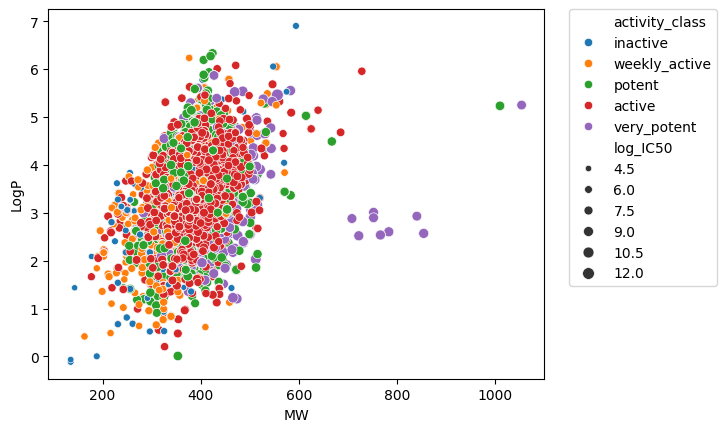

<Figure size 640x480 with 0 Axes>

In [ ]:
# observe the cistribution of the molecular weight and logP values of the compounds using scatter plot.
sns.scatterplot(x='MW', y='LogP', data=act_df3, hue='activity_class', size='log_IC50')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0)
plt.show()
plt.savefig('MW_vs_LogP.png')

In [ ]:
# create a df for each class.
very_potent = act_df3[act_df3['activity_class'] == 'very_potent']['MW']
potent = act_df3[act_df3['activity_class'] == 'potent']['MW']
active = act_df3[act_df3['activity_class'] == 'active']['MW']
weekly_active = act_df3[act_df3['activity_class'] == 'weekly_active']['MW']
inactive = act_df3[act_df3['activity_class'] == 'inactive']['MW']
groups = [very_potent, potent, active, weekly_active, inactive]

In [ ]:
# determine if there is statstical difference between the classes for molecular weight.
from scipy.stats import kruskal
h_stat, p_value = kruskal(*groups)
print('Statistics=%.3f, p=%.4f' % (h_stat, p_value)) # there is a highly significant difference between the groups.

Statistics=726.865, p=0.0000


In [ ]:
# compare the difference pairwise using Dunn's posthoc test.
from statsmodels.stats.multicomp import pairwise_tukeyhsd
tukey = pairwise_tukeyhsd(endog=act_df3['MW'], groups=act_df3['activity_class'])
print(tukey.summary())

       Multiple Comparison of Means - Tukey HSD, FWER=0.05        
   group1       group2    meandiff p-adj   lower    upper   reject
------------------------------------------------------------------
     active      inactive -30.8352    0.0 -41.8668 -19.8036   True
     active        potent   6.3852 0.0073   1.1808  11.5897   True
     active   very_potent  46.3033    0.0  39.4996   53.107   True
     active weekly_active -28.5165    0.0 -34.9932 -22.0399   True
   inactive        potent  37.2205    0.0  26.0535  48.3875   True
   inactive   very_potent  77.1386    0.0  65.1425  89.1346   True
   inactive weekly_active   2.3187 0.9837  -9.4949  14.1323  False
     potent   very_potent  39.9181    0.0   32.897  46.9392   True
     potent weekly_active -34.9018    0.0 -41.6064 -28.1972   True
very_potent weekly_active -74.8199    0.0 -82.8296 -66.8101   True
------------------------------------------------------------------


In [ ]:
# convert the tukey summary to df and export as csv.
tukey_df = pd.DataFrame(
    data=tukey._results_table.data[1:],  # skip header
    columns=tukey._results_table.data[0])
tukey_df.to_csv("tukey_results.csv", index=False)
tukey_df.head()

,group1,group2,meandiff,p-adj,lower,upper,reject
0,active,inactive,-30.8352,0.0000,-41.8668,-19.8036,True
1,active,potent,6.3852,0.0073,1.1808,11.5897,True
2,active,very_potent,46.3033,0.0000,39.4996,53.1070,True
3,active,weekly_active,-28.5165,0.0000,-34.9932,-22.0399,True
4,inactive,potent,37.2205,0.0000,26.0535,48.3875,True


## **LogP**

In [ ]:
# create a df for each class.
very_potent = act_df3[act_df3['activity_class'] == 'very_potent']['LogP']
potent = act_df3[act_df3['activity_class'] == 'potent']['LogP']
active = act_df3[act_df3['activity_class'] == 'active']['LogP']
weekly_active = act_df3[act_df3['activity_class'] == 'weekly_active']['LogP']
inactive = act_df3[act_df3['activity_class'] == 'inactive']['LogP']
groups_logP = [very_potent, potent, active, weekly_active, inactive]

In [ ]:
# determine if there is statstical difference between the classes for LogP.
h_stat, p_value = kruskal(*groups_logP)
print('Statistics=%.3f, p=%.4f' % (h_stat, p_value))

Statistics=20.740, p=0.0004


In [ ]:
# compare the difference pairwise using Dunn's posthoc test.
tukey = pairwise_tukeyhsd(endog=act_df3['LogP'], groups=act_df3['activity_class'])
print(tukey.summary())

      Multiple Comparison of Means - Tukey HSD, FWER=0.05       
   group1       group2    meandiff p-adj   lower   upper  reject
----------------------------------------------------------------
     active      inactive  -0.2111 0.0052 -0.3783 -0.0438   True
     active        potent  -0.0281 0.8674  -0.107  0.0508  False
     active   very_potent  -0.1077 0.0356 -0.2108 -0.0046   True
     active weekly_active  -0.0922 0.0777 -0.1904   0.006  False
   inactive        potent   0.1829 0.0266  0.0136  0.3522   True
   inactive   very_potent   0.1033 0.5294 -0.0785  0.2852  False
   inactive weekly_active   0.1189 0.3671 -0.0602  0.2979  False
     potent   very_potent  -0.0796 0.2469  -0.186  0.0269  False
     potent weekly_active  -0.0641 0.4218 -0.1657  0.0376  False
very_potent weekly_active   0.0155 0.9968 -0.1059  0.1369  False
----------------------------------------------------------------


## **HBD**

In [ ]:
# create a df for each class.
very_potent = act_df3[act_df3['activity_class'] == 'very_potent']['HBD']
potent = act_df3[act_df3['activity_class'] == 'potent']['HBD']
active = act_df3[act_df3['activity_class'] == 'active']['HBD']
weekly_active = act_df3[act_df3['activity_class'] == 'weekly_active']['HBD']
inactive = act_df3[act_df3['activity_class'] == 'inactive']['HBD']
groups_hbd = [very_potent, potent, active, weekly_active, inactive]

In [ ]:
# determine if there is statstical difference between the classes for HBD.
h_stat, p_value = kruskal(*groups_hbd)
print('Statistics=%.3f, p=%.4f' % (h_stat, p_value))

Statistics=120.139, p=0.0000


In [ ]:
# compare the difference pairwise using Dunn's posthoc test.
tukey = pairwise_tukeyhsd(endog=act_df3['HBD'], groups=act_df3['activity_class'])
print(tukey.summary())

      Multiple Comparison of Means - Tukey HSD, FWER=0.05       
   group1       group2    meandiff p-adj   lower   upper  reject
----------------------------------------------------------------
     active      inactive    -0.12 0.1525 -0.2638  0.0238  False
     active        potent  -0.1801    0.0  -0.248 -0.1122   True
     active   very_potent  -0.2529    0.0 -0.3416 -0.1642   True
     active weekly_active  -0.1821    0.0 -0.2666 -0.0977   True
   inactive        potent  -0.0601 0.7927 -0.2057  0.0855  False
   inactive   very_potent  -0.1329  0.139 -0.2893  0.0235  False
   inactive weekly_active  -0.0621 0.8065 -0.2161  0.0919  False
     potent   very_potent  -0.0728 0.1912 -0.1643  0.0187  False
     potent weekly_active   -0.002    1.0 -0.0894  0.0854  False
very_potent weekly_active   0.0708  0.345 -0.0336  0.1752  False
----------------------------------------------------------------


## **HBA**

In [ ]:
# create a df for each class.
very_potent = act_df3[act_df3['activity_class'] == 'very_potent']['HBA']
potent = act_df3[act_df3['activity_class'] == 'potent']['HBA']
active = act_df3[act_df3['activity_class'] == 'active']['HBA']
weekly_active = act_df3[act_df3['activity_class'] == 'weekly_active']['HBA']
inactive = act_df3[act_df3['activity_class'] == 'inactive']['HBA']
groups_hba = [very_potent, potent, active, weekly_active, inactive]

In [ ]:
# determine if there is statstical difference between the classes for HBA.
h_stat, p_value = kruskal(*groups_hba)
print('Statistics=%.3f, p=%.4f' % (h_stat, p_value))

Statistics=622.770, p=0.0000


In [ ]:
# compare the difference pairwise using Dunn's posthoc test.
tukey = pairwise_tukeyhsd(endog=act_df3['HBA'], groups=act_df3['activity_class'])
print(tukey.summary())

      Multiple Comparison of Means - Tukey HSD, FWER=0.05       
   group1       group2    meandiff p-adj   lower   upper  reject
----------------------------------------------------------------
     active      inactive  -0.8191    0.0 -1.0727 -0.5656   True
     active        potent   0.1222 0.0424  0.0026  0.2419   True
     active   very_potent   0.8514    0.0   0.695  1.0078   True
     active weekly_active  -0.8562    0.0  -1.005 -0.7073   True
   inactive        potent   0.9414    0.0  0.6847  1.1981   True
   inactive   very_potent   1.6706    0.0  1.3948  1.9463   True
   inactive weekly_active   -0.037 0.9959 -0.3086  0.2345  False
     potent   very_potent   0.7292    0.0  0.5678  0.8906   True
     potent weekly_active  -0.9784    0.0 -1.1325 -0.8243   True
very_potent weekly_active  -1.7076    0.0 -1.8917 -1.5235   True
----------------------------------------------------------------


In [ ]:
print(active.shape)
print(weekly_active.shape)
print(inactive.shape)
print(potent.shape)
print(very_potent.shape)

(2213,)
(891,)
(243,)
(1771,)
(778,)


## **3. Descriptor Calculation and Dataset Preparation**

### The fingerprints of the compounds is caclulated to be used for the machine learning.

In [ ]:
! pip install mordredcommunity

In [ ]:
from rdkit import Chem


In [ ]:
# act_df3 = act_df3[act_df3['activity_class'].isin(['very_potent','potent','active','weakly_active','inactive'])]
# act_df3.shape

In [ ]:
from mordred import Calculator, descriptors

In [ ]:
# from act_df3 df slice the chambel_id and canonical_smile features and save as .smi.
selected_features = ['molecule_chembl_id','canonical_smiles']
molecules = act_df3[selected_features]
molecules.to_csv('molecule.smi', sep='\t', index=False, header=False)

In [ ]:
! cat molecule.smi | head -5

CHEMBL1771409	Cc1cc(N/N=C/c2ccc(O)c(O)c2)nc2ccccc12
CHEMBL1771411	Cc1cc(N/N=C/c2ccncc2)nc2ccccc12
CHEMBL1933288	C[C@@H]1CCNC(=O)c2cc3ccc(C(=O)Nc4nc5ccccc5n4CCCN(C)C)cc3n21
CHEMBL2012582	COc1cc(C(=O)N2CCC(N3CCN(C)CC3)CC2)ccc1Nc1ncc2c(n1)N(C)c1ccccc1C(=O)N2C
CHEMBL509032	COc1cc(N2CCC(N3CCN(C)CC3)CC2)ccc1Nc1ncc(Cl)c(Nc2ccccc2S(=O)(=O)C(C)C)n1


In [ ]:
molecules.columns = ['ID','SMILES']
molecules.head()

,ID,SMILES
0,CHEMBL1771409,Cc1cc(N/N=C/c2ccc(O)c(O)c2)nc2ccccc12
1,CHEMBL1771411,Cc1cc(N/N=C/c2ccncc2)nc2ccccc12
2,CHEMBL1933288,C[C@@H]1CCNC(=O)c2cc3ccc(C(=O)Nc4nc5ccccc5n4CC...
3,CHEMBL2012582,COc1cc(C(=O)N2CCC(N3CCN(C)CC3)CC2)ccc1Nc1ncc2c...
4,CHEMBL509032,COc1cc(N2CCC(N3CCN(C)CC3)CC2)ccc1Nc1ncc(Cl)c(N...


In [ ]:
# create the colecule for which the descriptors are calculated.
mols = [Chem.MolFromSmiles(s) for s in molecules['SMILES']]
# # Calculate descriptors
calc = Calculator(descriptors, ignore_3D=True)
desc_df = calc.pandas(mols)

 17%|█▋        | 991/5896 [03:31<14:09,  5.77it/s]

In [ ]:
desc_df.info()

In [ ]:
# convert all columns of the desc_df to float
desc_df = desc_df.astype(float)
desc_df.info()

In [ ]:
#desc_df.to_csv('desc_df.csv')

In [ ]:
#desc_df = pd.read_csv('desc_df.csv')

In [ ]:
desc_df.head()

##**Clean the descriptors df**

In [ ]:
# calculate the mean percentage of nulls per descriptor.
missing_pct = desc_df.isnull().mean() * 100
desc_df_filtered = desc_df.loc[:, missing_pct < 20]
desc_df_filtered.shape

In [ ]:
# some columns contain totally null values. So, drop these columns.
desc_df1 = desc_df.dropna(axis=1)
desc_df1.shape

In [ ]:
# columns with less than 20% missing values.
num_cols = desc_df_filtered.shape[1] - desc_df1.shape[1]
num_cols # 377 columns have null values less than 20%.

### instead of droping the 377 descriptors with null values, impute the values with median. This helps to prevent the loss of compounds.

In [ ]:
clean_df = desc_df_filtered.copy()

In [ ]:
clean_df.shape

In [ ]:
# fill the missing values by the median of each descriptor.
clean_df = clean_df.fillna(clean_df.median())
clean_df.shape

## **4. ML with RandomForest regression model**

In [ ]:
# import the necessart lobraries
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
# Determine the numerical imput features X and target feature y
clean_df
y = act_df3['log_IC50']
print(X.shape)
print(y.shape)

In [ ]:
# The dataframe has 1613 features or desscriptors. Drop if there are non informative features.
from sklearn.feature_selection import VarianceThreshold
selection = VarianceThreshold(threshold=(.8 * (1 - .8)))
X_df = selection.fit_transform(clean_df)
df_filt = pd.DataFrame(X_df)
print(df_filt.shape)

In [ ]:
# remove highly correlated features.
corr_matrix = df_filt.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(np.bool))

In [ ]:
to_drop = [col for col in upper.columns if any(upper[col] > 0.95)]
df_filt = df_filt.drop(columns=to_drop)
print(df_filt.shape)

In [ ]:
# scale X
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_filt)

## The variance threshold removed nearly 800 features.

In [ ]:
X = df_filt

In [ ]:
# split X aand y to train and test sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

In [ ]:
# use random forest for regression.
model = RandomForestRegressor(n_estimators=100, random_state=42)
score = cross_val_score(model, X, y, cv=5, scoring='r2')
print("R² scores:", score)
print("Mean R²:", score.mean())
print("Std R²:", score.std())

In [ ]:
accuracy = r2_score(y_test, y_pred)
accuracy

In [ ]:
model = ExtraTreesRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [ ]:
accuracy1 = r2_score(y_test, y_pred)
accuracy1

##**Compare difference regressors**

In [ ]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.model_selection import cross_val_score

In [ ]:
models = {"Ridge": Ridge(), "Lasso": Lasso(), "ElasticNet": ElasticNet(), "RandomForest": RandomForestRegressor(random_state=42),
"ExtraTrees": ExtraTreesRegressor(random_state=42)}
results = []
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5, scoring='r2', n_jobs=-1)
    results.append({"Model": name, "Mean_R2": scores.mean(), "Std_R2": scores.std()})
results_df = pd.DataFrame(results)

print(results_df.sort_values("Mean_R2", ascending=False))